In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv('data.csv')

print(df.shape)
df.info()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [2]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df['TotalCharges'].isnull().sum())

11


In [4]:
df.dropna(inplace=True)

print(df.shape)
print(df.isnull().sum().sum())

(7032, 21)
0


In [5]:
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(df[['tenure', 'tenure_group']].head())

   tenure tenure_group
0       1         0-12
1      34        25-36
2       2         0-12
3      45        37-48
4       2         0-12


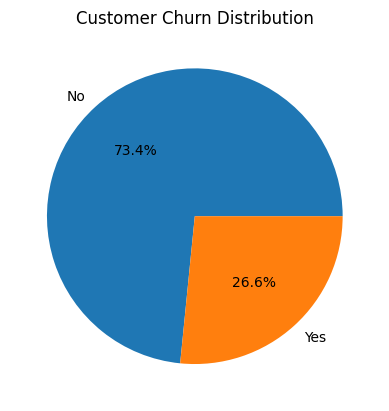

In [6]:
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Customer Churn Distribution')
plt.ylabel('')
plt.show()

In [7]:
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

print(X.shape)
print(y.value_counts())

(7032, 20)
Churn
0    5163
1    1869
Name: count, dtype: int64


In [8]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = X.select_dtypes(include=['object', 'category']).columns

label_encoders = {}

for column in categorical_columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column].astype(str))
    label_encoders[column] = le

print(X.head())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1                 

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 20)
X_test : (1407, 20)
y_train: (5625,)
y_test : (1407,)


In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())

Churn
0    4130
1    4130
Name: count, dtype: int64


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("KNN Classification Accuracy:", accuracy)
print("Accuracy in percentage:", accuracy * 100, "%")

KNN Classification Accuracy: 0.7114427860696517
Accuracy in percentage: 71.14427860696517 %


In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.47026022304832715
Recall: 0.6764705882352942
F1 Score: 0.5548245614035088


[[748 285]
 [121 253]]


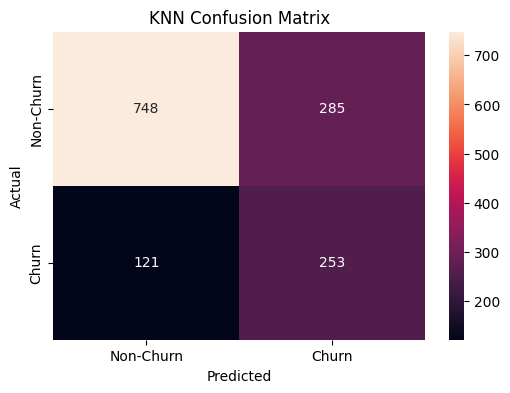

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Non-Churn', 'Churn'],
    yticklabels=['Non-Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')

plt.show()

In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['Non-Churn', 'Churn']
))

              precision    recall  f1-score   support

   Non-Churn       0.86      0.72      0.79      1033
       Churn       0.47      0.68      0.55       374

    accuracy                           0.71      1407
   macro avg       0.67      0.70      0.67      1407
weighted avg       0.76      0.71      0.72      1407



In [17]:
import pickle

pickle.dump(knn, open("knn_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(label_encoders, open("label_encoders.pkl", "wb"))

print("Models saved successfully!")

Models saved successfully!
